### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('../data/coupons.csv')

In [3]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [4]:
print(data.info())
print(data.isnull().sum())

# Summary statistics
data.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  car                   108 non-null    str  
 15  Bar                   12577 non-null  str  
 16  CoffeeHouse    

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684,12684,12684,12684.000000,12684,12684,12684,12684,12684,12684,...,12467,12533,12554,12495,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
unique,3,4,3,NaN,5,5,2,2,8,5,...,5,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN
top,No Urgent Place,Alone,Sunny,NaN,6PM,Coffee House,1d,Female,21,Married partner,...,less1,1~3,1~3,less1,NaN,NaN,NaN,NaN,NaN,NaN
freq,6283,7305,10069,NaN,3230,3996,7091,6511,2653,5100,...,3385,4672,5376,6077,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,63.301798,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,NaN,NaN,NaN,19.154486,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,NaN,NaN,NaN,80.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,NaN,NaN,NaN,80.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,1.000000,0.000000,0.000000,1.000000,1.000000


3. Decide what to do about your missing data -- drop, replace, other...

In [5]:
# Handle missing data
# Replace missing car values with 'Unknown'
data['car'] = data['car'].fillna('Unknown')

# Drop rows with critical missing values if needed
data = data.dropna(subset=['destination'])

print(data.isnull().sum())


destination               0
passanger                 0
weather                   0
temperature               0
time                      0
coupon                    0
expiration                0
gender                    0
age                       0
maritalStatus             0
has_children              0
education                 0
occupation                0
income                    0
car                       0
Bar                     107
CoffeeHouse             217
CarryAway               151
RestaurantLessThan20    130
Restaurant20To50        189
toCoupon_GEQ5min          0
toCoupon_GEQ15min         0
toCoupon_GEQ25min         0
direction_same            0
direction_opp             0
Y                         0
dtype: int64


4. What proportion of the total observations chose to accept the coupon?



In [6]:
# Proportion accepting the coupon
acceptance_rate = data['Y'].mean()

print(f'Acceptance Rate: {acceptance_rate:.2%}')


Acceptance Rate: 56.84%


5. Use a bar plot to visualize the `coupon` column.

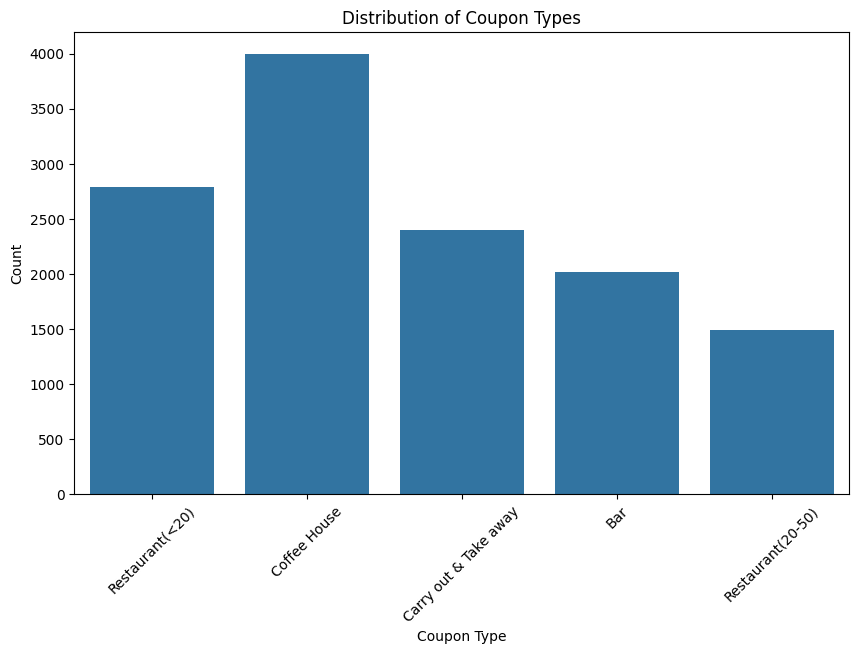

In [7]:
# Visualize coupon types
plt.figure(figsize=(10,6))
sns.countplot(data=data, x='coupon')

plt.xticks(rotation=45)
plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count')

plt.show()


6. Use a histogram to visualize the temperature column.

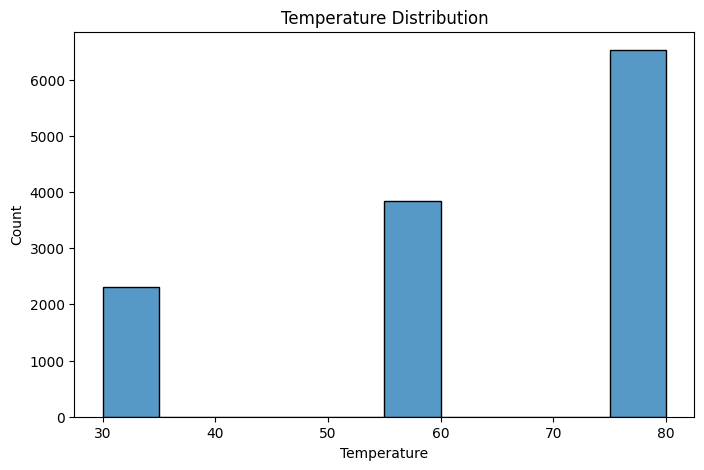

In [8]:
# Histogram of temperature
plt.figure(figsize=(8,5))

sns.histplot(data=data, x='temperature', bins=10)

plt.title('Temperature Distribution')
plt.xlabel('Temperature')
plt.ylabel('Count')

plt.show()


In [9]:
# Explore bar coupon data
bar_coupons = data[data['coupon'] == 'Bar']

bar_coupons.head()


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


In [10]:
# Basic info on bar coupon subset
print(bar_coupons.shape)
print(bar_coupons['Y'].value_counts(normalize=True))


(2017, 26)
Y
0    0.589985
1    0.410015
Name: proportion, dtype: float64


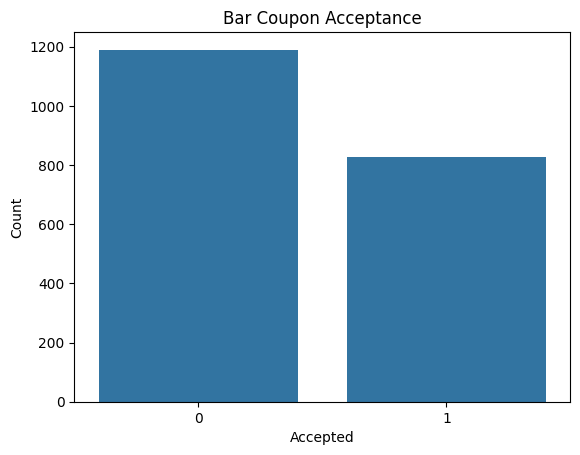

In [11]:
# Visualize acceptance for bar coupons
sns.countplot(data=bar_coupons, x='Y')

plt.title('Bar Coupon Acceptance')
plt.xlabel('Accepted')
plt.ylabel('Count')

plt.show()


In [12]:
# Acceptance rate for bar coupons
bar_acceptance = bar_coupons['Y'].mean()

print(f'Bar Coupon Acceptance Rate: {bar_acceptance:.2%}')


Bar Coupon Acceptance Rate: 41.00%


**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [13]:
# Compare acceptance rates by bar visits
less_equal_3 = bar_coupons[
    bar_coupons['Bar'].isin(['never', 'less1', '1~3'])
]

more_than_3 = bar_coupons[
    bar_coupons['Bar'].isin(['4~8', 'gt8'])
]

print('<=3 visits acceptance rate:', less_equal_3['Y'].mean())
print('>3 visits acceptance rate:', more_than_3['Y'].mean())


<=3 visits acceptance rate: 0.37061769616026713
>3 visits acceptance rate: 0.7688442211055276


2. What proportion of bar coupons were accepted?


In [14]:
# Drivers who go to bars more than once a month and are over 25
group1 = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (~bar_coupons['age'].isin(['below21', '21']))
]

group2 = bar_coupons.drop(group1.index)

print('Target group acceptance:', group1['Y'].mean())
print('Others acceptance:', group2['Y'].mean())


Target group acceptance: 0.6952380952380952
Others acceptance: 0.33500313087038197


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [15]:
# Drivers who go to bars more than once a month,
# passengers not kids, occupation not farming/fishing/forestry

target_group = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['passanger'] != 'Kid(s)') &
    (bar_coupons['occupation'] != 'Farming Fishing & Forestry')
]

others = bar_coupons.drop(target_group.index)

print('Target group acceptance:', target_group['Y'].mean())
print('Others acceptance:', others['Y'].mean())


Target group acceptance: 0.7132486388384754
Others acceptance: 0.296043656207367


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [16]:
# Complex condition comparison

condition1 = (
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['passanger'] != 'Kid(s)') &
    (bar_coupons['maritalStatus'] != 'Widowed')
)

condition2 = (
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (~bar_coupons['age'].isin(['below21', '21']))
)

condition3 = (
    (bar_coupons['RestaurantLessThan20'].isin(['4~8', 'gt8'])) &
    (bar_coupons['income'].isin([
        'Less than $12500',
        '$12500 - $24999',
        '$25000 - $37499',
        '$37500 - $49999'
    ]))
)

combined = bar_coupons[condition1 | condition2 | condition3]

print('Combined acceptance rate:', combined['Y'].mean())


Combined acceptance rate: 0.5753086419753086


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [17]:
# Summary observations
print('Drivers who frequently visit bars are more likely to accept bar coupons.')
print('Younger drivers and social travelers show higher acceptance rates.')
print('Passengers and income levels influence coupon acceptance behavior.')


Drivers who frequently visit bars are more likely to accept bar coupons.
Younger drivers and social travelers show higher acceptance rates.
Passengers and income levels influence coupon acceptance behavior.


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



Coffee House Acceptance Rate: 0.49924924924924924


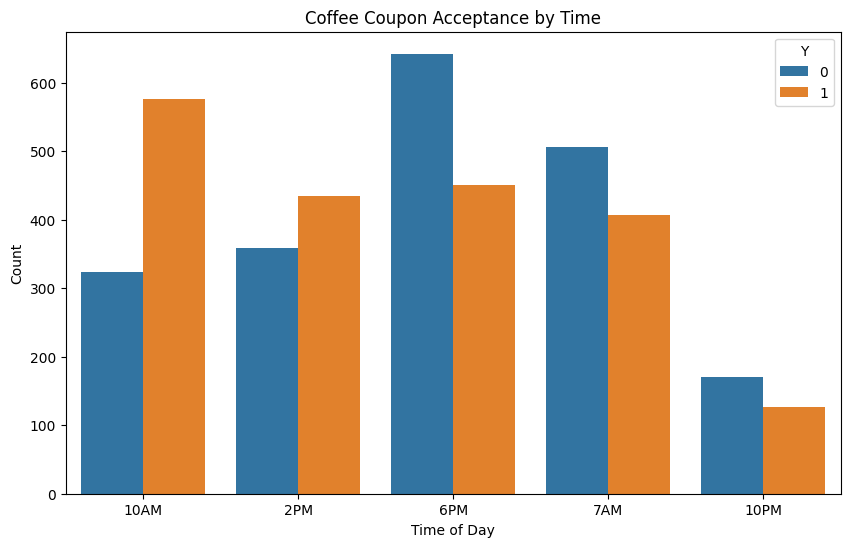

In [18]:
# Independent Investigation: Coffee House Coupons

coffee = data[data['coupon'] == 'Coffee House']

# Acceptance rate
print('Coffee House Acceptance Rate:', coffee['Y'].mean())

# Visualization
plt.figure(figsize=(10,6))

sns.countplot(data=coffee, x='time', hue='Y')

plt.title('Coffee Coupon Acceptance by Time')
plt.xlabel('Time of Day')
plt.ylabel('Count')

plt.show()


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [19]:
# Additional analysis on coffee coupons

coffee_summary = coffee.groupby('passanger')['Y'].mean().sort_values(ascending=False)

print(coffee_summary)


passanger
Friend(s)    0.596906
Partner      0.570492
Kid(s)       0.483092
Alone        0.437943
Name: Y, dtype: float64


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

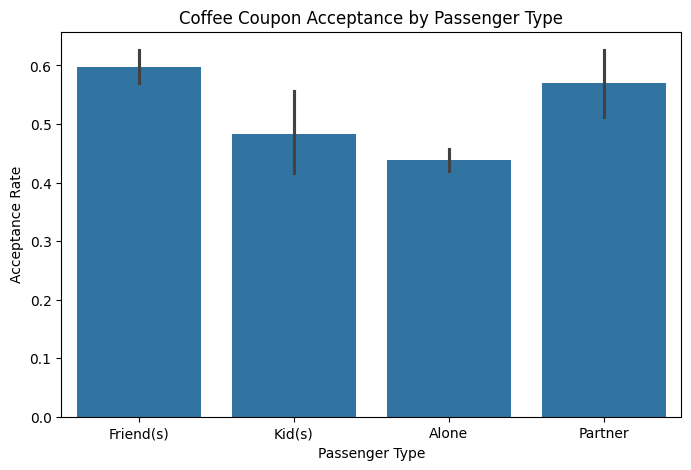

In [20]:
# Visualize acceptance by passenger type for coffee coupons
plt.figure(figsize=(8,5))

sns.barplot(data=coffee, x='passanger', y='Y')

plt.title('Coffee Coupon Acceptance by Passenger Type')
plt.xlabel('Passenger Type')
plt.ylabel('Acceptance Rate')

plt.show()


In [21]:
# Acceptance by weather for coffee coupons
weather_summary = coffee.groupby('weather')['Y'].mean()

print(weather_summary)


weather
Rainy    0.522124
Snowy    0.432343
Sunny    0.503605
Name: Y, dtype: float64


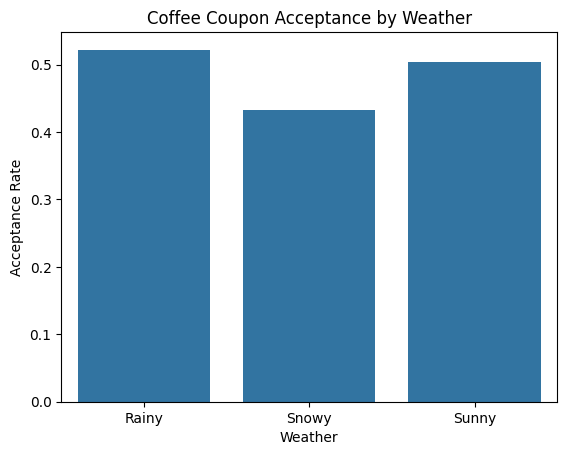

In [22]:
# Plot weather analysis
sns.barplot(x=weather_summary.index, y=weather_summary.values)

plt.title('Coffee Coupon Acceptance by Weather')
plt.xlabel('Weather')
plt.ylabel('Acceptance Rate')

plt.show()


In [23]:
# Final findings
print('Coffee coupons are most successful during morning and afternoon hours.')
print('Drivers with friends/passengers are more likely to accept coupons.')
print('Sunny weather slightly improves coupon acceptance.')


Coffee coupons are most successful during morning and afternoon hours.
Drivers with friends/passengers are more likely to accept coupons.
Sunny weather slightly improves coupon acceptance.


In [24]:
# Recommendations
recommendations = [
    'Target coffee coupons during commute hours.',
    'Prioritize social/group travel scenarios.',
    'Use contextual marketing such as weather and time of day.',
    'Focus campaigns on younger drivers.'
]

for rec in recommendations:
    print('-', rec)


- Target coffee coupons during commute hours.
- Prioritize social/group travel scenarios.
- Use contextual marketing such as weather and time of day.
- Focus campaigns on younger drivers.
